In [ ]:
!pip install pubchempy rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 23.0 MB/s eta 0:00:00


In [ ]:
#1. Import
import ast
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import Descriptors

In [ ]:
#2. Load dataset
print("Loading DrugReasoner dataset from Hugging Face...")
dataset = load_dataset("Moreza009/drug_approval_prediction")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas() if "test" in dataset else None
df_val = dataset["validation"].to_pandas() if "validation" in dataset else None

print("Train:",df_train.shape)
print("Test:",df_test.shape)
print("Validation:",df_val.shape)

Loading DrugReasoner dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.49M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/320k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/321k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/3608 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/451 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

Generating external split:   0%|          | 0/25 [00:00<?, ? examples/s]

Train: (3608, 5)
Test: (451, 5)
Validation: (451, 5)


In [ ]:
#3. Identify target and feature columns
TARGET_COL = "label"

#4. Feature Extraction - Convert SMILES to RDKit Descriptors
def smiles_to_descriptors(smiles):
    """
    Convert a SMILES string to a set of RDKit molecular descriptors.
    If SMILES is invalid, return NaNs.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        desc = {
            "MolWt": Descriptors.MolWt(mol),
            "LogP": Descriptors.MolLogP(mol),
            "NumHDonors": Descriptors.NumHDonors(mol),
            "NumHAcceptors": Descriptors.NumHAcceptors(mol),
            "TPSA": Descriptors.TPSA(mol),
            "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
            "RingCount": Descriptors.RingCount(mol),
        }
        return desc
    except:
        return None

def add_descriptor_features(df, smiles_col="smiles"):
    """
    Add RDKit descriptor features from SMILES column to the dataframe.
    """
    descriptor_list = []
    for s in df[smiles_col].fillna(""):
        desc = smiles_to_descriptors(s)
        descriptor_list.append(desc)
    desc_df = pd.DataFrame(descriptor_list)
    return pd.concat([df.reset_index(drop=True), desc_df.reset_index(drop=True)], axis=1)

# Add descriptors
print("\nGenerating RDKit descriptor features...")
df_train = add_descriptor_features(df_train, smiles_col="smiles")
df_test = add_descriptor_features(df_test, smiles_col="smiles") if df_test is not None else None
df_val = add_descriptor_features(df_val, smiles_col="smiles") if df_val is not None else None

# Drop rows with failed descriptor extraction (NaNs)
df_train = df_train.dropna(subset=["MolWt", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds", "RingCount"])
df_val = df_val.dropna(subset=["MolWt", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds", "RingCount"])
df_test = df_test.dropna(subset=["MolWt", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds", "RingCount"])

print("Train after descriptor extraction:", df_train.shape)
print("Val after descriptor extraction:", df_val.shape)
print("Test after descriptor extraction:", df_test.shape)

# Basic check label distribution
print("\nLabel distribution (train):")
print(df_train[TARGET_COL].value_counts(normalize=True))

#5. Define feature set
FEATURE_COLS = [
    "MolWt",
    "LogP",
    "NumHDonors",
    "NumHAcceptors",
    "TPSA",
    "NumRotatableBonds",
    "RingCount",
]

def remove_duplicate_columns(df):
    dupes = df.columns[df.columns.duplicated()].tolist()
    if dupes:
        print("Removed duplicated columns:", dupes)
    return df.loc[:, ~df.columns.duplicated()]

df_train = remove_duplicate_columns(df_train)
df_val   = remove_duplicate_columns(df_val)
df_test  = remove_duplicate_columns(df_test)

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]

X_val = df_val[FEATURE_COLS]
y_val = df_val[TARGET_COL]

X_test = df_test[FEATURE_COLS]
y_test = df_test[TARGET_COL]


Generating RDKit descriptor features...


[19:37:22] WARNING: not removing hydrogen atom without neighbors
[19:37:22] WARNING: not removing hydrogen atom without neighbors
[19:37:22] WARNING: not removing hydrogen atom without neighbors
[19:37:22] WARNING: not removing hydrogen atom without neighbors
[19:37:24] WARNING: not removing hydrogen atom without neighbors
[19:37:24] WARNING: not removing hydrogen atom without neighbors


Train after descriptor extraction: (3608, 19)
Val after descriptor extraction: (451, 19)
Test after descriptor extraction: (451, 19)

Label distribution (train):
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Removed duplicated columns: ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds', 'RingCount']
Removed duplicated columns: ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds', 'RingCount']
Removed duplicated columns: ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds', 'RingCount']


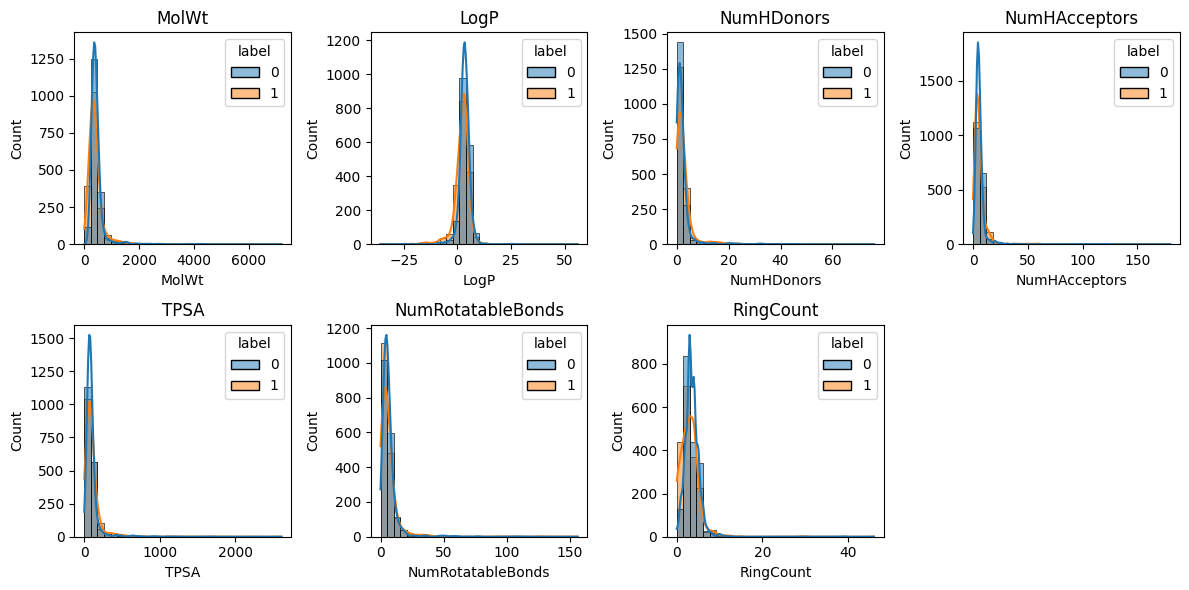

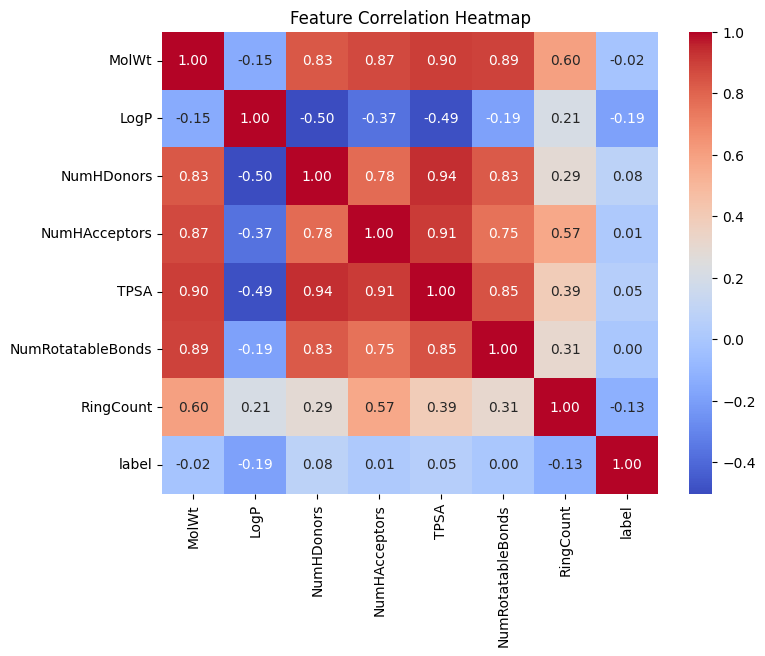

In [ ]:
#6. Basic EDA - Distribution plots
plt.figure(figsize=(12, 6))
for i, col in enumerate(FEATURE_COLS):
    plt.subplot(2, 4, i + 1)
    sns.histplot(data=df_train, x=col, hue=TARGET_COL, kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

#7. Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df_train[FEATURE_COLS + [TARGET_COL]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#8. Models set up
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42),
    ),
    "K-Nearest Neighbors": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(),
    ),
    "Support Vector Machine": make_pipeline(
        StandardScaler(),
        SVC(probability=True, random_state=42),
    ),
    "Random Forest": make_pipeline(
        StandardScaler(),
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        ),
    ),
    "XGBoost": make_pipeline(
        StandardScaler(),
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1,
        ),
    ),
}


These features are basic molecular properties derived from SMILES.
We will train multiple classification models to predict whether a drug is approved (1) or failed (0).
We use ROC AUC as the main metric to compare models (higher is better).



Training models and evaluating on validation set (ROC AUC)...
Logistic Regression       | Val ROC AUC: 0.680
K-Nearest Neighbors       | Val ROC AUC: 0.697
Support Vector Machine    | Val ROC AUC: 0.722
Random Forest             | Val ROC AUC: 0.733
XGBoost                   | Val ROC AUC: 0.724

Summary of validation performance (sorted by Val_ROC_AUC):
                    Model  Val_ROC_AUC
3           Random Forest     0.733107
4                 XGBoost     0.723795
2  Support Vector Machine     0.722281
1     K-Nearest Neighbors     0.696735
0     Logistic Regression     0.680138


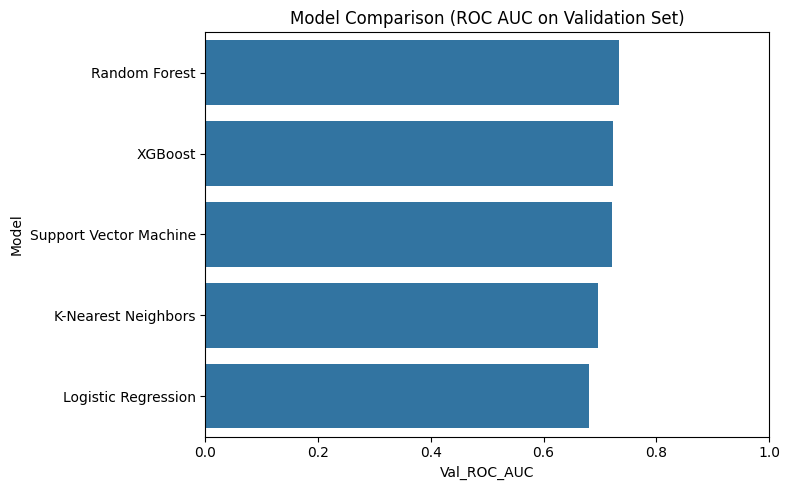


Best model selected based on validation set: Random Forest


In [ ]:
#9. Train + evaluate on validation set
trained_models = {}
results = []

print("\nTraining models and evaluating on validation set (ROC AUC)...")
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    # predict probabilities for AUC
    y_proba_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_proba_val)

    results.append({"Model": name, "Val_ROC_AUC": val_auc})
    print(f"{name:25s} | Val ROC AUC: {val_auc:.3f}")

results_val_df = pd.DataFrame(results).sort_values(
    by="Val_ROC_AUC", ascending=False
)
print("\nSummary of validation performance (sorted by Val_ROC_AUC):")
print(results_val_df)

# Bar plot of validation ROC AUC for comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=results_val_df, x="Val_ROC_AUC", y="Model")
plt.title("Model Comparison (ROC AUC on Validation Set)")
plt.xlim(0.0, 1.0)
plt.tight_layout()
plt.show()

#11. Use best model and evaluate on Test set
best_model_name = results_val_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\nBest model selected based on validation set: {best_model_name}")


Starting hyperparameter tuning for the best model (CV on TRAIN set)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC AUC: 0.7551
Best hyperparameters:
{'randomforestclassifier__n_estimators': 400, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': 50, 'randomforestclassifier__bootstrap': True}
Tuned model ROC AUC on VALIDATION set: 0.733

Classification report of the best model on the TEST set:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       226
           1       0.73      0.72      0.72       225

    accuracy                           0.73       451
   macro avg       0.73      0.73      0.73       451
weighted avg       0.73      0.73      0.73       451

Final TEST ROC AUC: 0.807


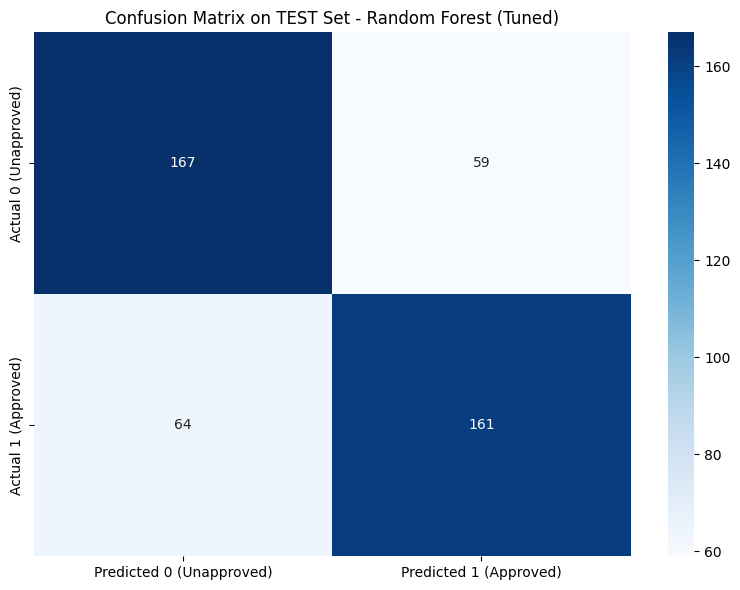

In [ ]:
# -------------------------------
# Hyperparameter tuning (best model)
# -------------------------------
# We tune ONLY the best-performing model (based on validation ROC AUC) using CV on the training set.
# Existing pipeline/model definitions above are unchanged.

def get_estimator_step_name(pipeline):
    if hasattr(pipeline, "named_steps") and pipeline.named_steps:
        return list(pipeline.named_steps.keys())[-1]
    return None

def build_param_distributions(pipeline):
    step = get_estimator_step_name(pipeline)
    if step is None:
        return {}

    est = pipeline.named_steps[step]

    # Parameter names must be prefixed with '<step>__' for pipelines
    if isinstance(est, LogisticRegression):
        return {
            f"{step}__C": [0.01, 0.1, 1, 3, 10, 30, 100],
            f"{step}__penalty": ["l2"],
            f"{step}__solver": ["lbfgs", "liblinear", "saga"],
            f"{step}__class_weight": [None, "balanced"],
            f"{step}__max_iter": [1000, 2000, 4000],
        }

    if isinstance(est, KNeighborsClassifier):
        return {
            f"{step}__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
            f"{step}__weights": ["uniform", "distance"],
            f"{step}__p": [1, 2],  # 1=Manhattan, 2=Euclidean
        }

    if isinstance(est, SVC):
        return {
            f"{step}__C": [0.1, 1, 3, 10, 30, 100],
            f"{step}__kernel": ["rbf", "linear", "poly"],
            f"{step}__gamma": ["scale", "auto"],
            f"{step}__class_weight": [None, "balanced"],
            f"{step}__degree": [2, 3, 4],  # used for poly
        }

    if isinstance(est, RandomForestClassifier):
        return {
            f"{step}__n_estimators": [200, 400, 600, 800, 1000],
            f"{step}__max_depth": [None, 5, 10, 20, 30, 50],
            f"{step}__min_samples_split": [2, 5, 10, 20],
            f"{step}__min_samples_leaf": [1, 2, 4, 8],
            f"{step}__max_features": ["sqrt", "log2", None],
            f"{step}__bootstrap": [True, False],
        }

    if isinstance(est, XGBClassifier):
        return {
            f"{step}__n_estimators": [200, 400, 600, 800, 1000],
            f"{step}__max_depth": [3, 4, 5, 6, 8, 10],
            f"{step}__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            f"{step}__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
            f"{step}__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
            f"{step}__min_child_weight": [1, 2, 5, 10],
            f"{step}__reg_lambda": [0.0, 0.5, 1.0, 2.0, 5.0],
        }

    return {}

# Clone the original (unfitted) best pipeline for tuning
base_best_pipeline = clone(models[best_model_name])
param_distributions = build_param_distributions(base_best_pipeline)

if len(param_distributions) == 0:
    print(f"Skipping tuning: no parameter space defined for model '{best_model_name}'.")
    tuned_best_model = best_model
    tuned_best_model_name = best_model_name
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=base_best_pipeline,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )

    print("\nStarting hyperparameter tuning for the best model (CV on TRAIN set)...")
    search.fit(X_train, y_train)

    tuned_best_model = search.best_estimator_
    tuned_best_model_name = f"{best_model_name} (Tuned)"

    print("\nBest CV ROC AUC:", round(search.best_score_, 4))
    print("Best hyperparameters:")
    print(search.best_params_)

    # Quick check on validation set (same holdout as your model zoo ranking)
    tuned_val_proba = tuned_best_model.predict_proba(X_val)[:, 1]
    tuned_val_auc = roc_auc_score(y_val, tuned_val_proba)
    print(f"Tuned model ROC AUC on VALIDATION set: {tuned_val_auc:.3f}")

# Replace best_model with the tuned version for downstream evaluation/analysis
best_model = tuned_best_model
best_model_name = tuned_best_model_name

#Evaluate on test data
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

print("\nClassification report of the best model on the TEST set:")
print(classification_report(y_test, y_pred_test))

test_auc = roc_auc_score(y_test, y_proba_test)
print(f"Final TEST ROC AUC: {test_auc:.3f}")

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 (Unapproved)", "Predicted 1 (Approved)"],
    yticklabels=["Actual 0 (Unapproved)", "Actual 1 (Approved)"],
)
plt.title(f"Confusion Matrix on TEST Set - {best_model_name}")
plt.tight_layout()
plt.show()



*   Best Model: Random Forrest
*   Best Parameter:{'randomforestclassifier__n_estimators': 400, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': 50, 'randomforestclassifier__bootstrap': True}



In [ ]:
# =========================
# INTERACTIVE MENU (FINAL)
# Option 1 & 3 styled like your FIRST ipynb
# + Option 2 added for SMILES
# Paste this at the END of your notebook (after best_model is trained)
# =========================

import numpy as np
import pandas as pd

# ---- REQUIRED: PubChem + RDKit already imported in your notebook ----
# Uses: pcp, Chem, Descriptors (already in your project)
# If not, uncomment:
# import pubchempy as pcp
# from rdkit import Chem
# from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen

# -------------------------------------------------------------------
# 1) Feature mapping: your current model uses FEATURE_COLS like:
#    ["MolWt","LogP","NumHDonors","NumHAcceptors","TPSA","NumRotatableBonds","RingCount"]
#    But your "first ipynb" menu uses pretty labels.
# -------------------------------------------------------------------

PRETTY_TO_MODEL = {
    "Molecular Weight": "MolWt",
    "LogP": "LogP",
    "Molecular Refractivity": "MolMR",     # display-only (not in model input)
    "TPSA": "TPSA",
    "Hydrogen Bond_Donors": "NumHDonors",
    "Hydrogen_Bond Acceptors": "NumHAcceptors",
    "Rotatable Bonds": "NumRotatableBonds",
    "RingCount": "RingCount",
}

MODEL_TO_PRETTY = {v: k for k, v in PRETTY_TO_MODEL.items()}

# If your notebook already defines FEATURE_COLS, we use it.
# Otherwise fallback:
try:
    FEATURE_COLS
except NameError:
    FEATURE_COLS = ["MolWt","LogP","NumHDonors","NumHAcceptors","TPSA","NumRotatableBonds","RingCount"]

# -------------------------------------------------------------------
# 2) Make predictions in EXACT fitted feature order (avoids sklearn error)
# -------------------------------------------------------------------
def get_fitted_feature_order(model, fallback_cols):
    est = model
    if hasattr(model, "named_steps") and model.named_steps:
        last_key = list(model.named_steps.keys())[-1]
        est = model.named_steps[last_key]
    if hasattr(est, "feature_names_in_"):
        return list(est.feature_names_in_)
    return list(fallback_cols)

def predict_with_order(model, feature_dict):
    fitted_cols = get_fitted_feature_order(model, FEATURE_COLS)

    # build row exactly in training order
    row = {c: float(feature_dict.get(c, 0.0)) for c in fitted_cols}
    X = pd.DataFrame([row], columns=fitted_cols)

    try:
        proba = float(model.predict_proba(X)[:, 1][0])
        pred = int(model.predict(X)[0])
        return pred, proba
    except ValueError as e:
        # Fallback: feed numpy (removes feature-name enforcement)
        X_np = X.values.astype(float)
        proba = float(model.predict_proba(X_np)[:, 1][0])
        pred = int(model.predict(X_np)[0])
        return pred, proba

# -------------------------------------------------------------------
# 3) Compute descriptors from SMILES (for options 1 & 2)
#    Returns dict with model features + MolMR for display
# -------------------------------------------------------------------
def compute_from_smiles(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES. Please try again.")

    feats = {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "MolMR": Crippen.MolMR(mol),  # display-only
    }
    return feats

def safe_smiles_preview(smiles, max_len=60):
    return smiles if len(smiles) <= max_len else smiles[:max_len] + "..."

# -------------------------------------------------------------------
# 4) Simple "Normal/High" heuristics (to match your sample outputs)
# -------------------------------------------------------------------
def interpret_feature(pretty_name, value):
    notes = []
    status = "Normal"

    if pretty_name == "Molecular Weight":
        if value < 150:
            status = "Low"
        elif value > 500:
            status = "High"

    elif pretty_name == "LogP":
        if value < 1:
            status = "Low"
        elif value > 5:
            status = "High"

    elif pretty_name == "TPSA":
        if value < 20:
            status = "Low"
        elif value > 140:
            status = "High"

    elif pretty_name == "Rotatable Bonds":
        if value < 1:
            status = "Low"
        elif value > 10:
            status = "High"

    elif pretty_name == "Hydrogen_Bond Acceptors":
        if value < 1:
            status = "Low"
        elif value > 10:
            status = "High"

    elif pretty_name == "Hydrogen Bond_Donors":
        if value < 1:
            status = "Low"
        elif value > 5:
            status = "High"

    elif pretty_name == "Molecular Refractivity":
        if value < 40:
            status = "Low"
        elif value > 120:
            status = "High"

    return status, notes

# -------------------------------------------------------------------
# 5) PubChem lookup (option 1)
# -------------------------------------------------------------------
def pubchem_get_smiles(drug_name: str):
    compounds = pcp.get_compounds(drug_name, "name")
    if not compounds:
        return None, None
    c = compounds[0]
    smiles = getattr(c, "canonical_smiles", None)
    # Use IUPAC if available; else uppercase input
    name_id = getattr(c, "iupac_name", None)
    name_id = str(name_id).upper() if name_id else drug_name.upper()
    return name_id, smiles

# -------------------------------------------------------------------
# 6) Output printer (matches your first ipynb style)
# -------------------------------------------------------------------
def print_prediction_block(name_id, smiles, pred, proba, display_feats):
    print("\n" + "=" * 50)
    print(f"NAME/ID: {name_id}")
    print(f"SMILES (Digital Chemical Formula): {safe_smiles_preview(smiles)}")
    print("=" * 50)

    label = "APPROVED (SAFE)" if pred == 1 else "FAILED (TOXIC)"
    print(f"PREDICTION: {label}")
    print(f"APPROVAL PROBABILITY: {proba*100:.2f}%")
    print("-" * 50)
    print("KEY CONTRIBUTING FACTORS:")

    # Show in the same order as your sample (MR, MW, TPSA, LogP, RotB, HBA, HBD)
    pretty_order = [
        "Molecular Refractivity",
        "Molecular Weight",
        "TPSA",
        "LogP",
        "Rotatable Bonds",
        "Hydrogen_Bond Acceptors",
        "Hydrogen Bond_Donors",
    ]

    # Convert model feats -> pretty feats
    pretty_values = {}

    # MR (display-only)
    if "MolMR" in display_feats:
        pretty_values["Molecular Refractivity"] = float(display_feats["MolMR"])

    # model features -> pretty
    for model_key in FEATURE_COLS:
        pretty = MODEL_TO_PRETTY.get(model_key, model_key)
        pretty_values[pretty] = float(display_feats.get(model_key, 0.0))

    # Print exactly 7 lines like your example
    idx = 1
    for pretty_name in pretty_order:
        if pretty_name not in pretty_values:
            continue
        val = pretty_values[pretty_name]
        status, notes = interpret_feature(pretty_name, val)
        print(f"   {idx}. {pretty_name:23s}: {val:.2f} ({status})")
        for n in notes:
            print(f"      {n}")
        idx += 1
        if idx > 7:
            break

    print("=" * 50)

# -------------------------------------------------------------------
# 7) Option 1: Search by Name (keep same style)
# -------------------------------------------------------------------
def option_search_by_name(model):
    drug_name = input("Enter Drug Name (e.g., Aspirin): ").strip()
    print(f"   Searching PubChem for '{drug_name}'...")

    name_id, smiles = pubchem_get_smiles(drug_name)
    if smiles is None:
        print("\nNo result found on PubChem. Try a different drug name.")
        return

    feats = compute_from_smiles(smiles)
    pred, proba = predict_with_order(model, feats)
    print_prediction_block(name_id, smiles, pred, proba, feats)

# -------------------------------------------------------------------
# 8) Option 2: Check by SMILES (NEW)
# -------------------------------------------------------------------
def option_check_by_smiles(model):
    print("\nExample SMILES: CC(=O)OC1=CC=CC=C1C(=O)O (Aspirin)")
    smiles = input("Enter SMILES Code: ").strip()
    print("   Calculating properties from structure...")

    try:
        feats = compute_from_smiles(smiles)
    except ValueError as e:
        print(str(e))
        return

    pred, proba = predict_with_order(model, feats)
    print_prediction_block("CUSTOM MOLECULE", smiles, pred, proba, feats)

# -------------------------------------------------------------------
# 9) Option 3: Manual feature input (keep same style as first ipynb)
#    (We ask with the same pretty feature names, then map to your model features)
# -------------------------------------------------------------------
def option_manual_features(model):
    print("\nYou selected: NEW DRUG (manual molecular features).")
    print("Please enter the molecular features for the new drug.")
    print("If unsure, press Enter to set a value to 0.0.\n")

    VALID_RANGES = {
        "Molecular Weight": (0, 1500),
        "LogP": (-10, 10),
        "Molecular Refractivity": (0, 300),      # display-only; model ignores if not used
        "TPSA": (0, 300),
        "Hydrogen Bond_Donors": (0, 20),
        "Hydrogen_Bond Acceptors": (0, 20),
        "Rotatable Bonds": (0, 50),
        # RingCount isn't in your first-menu manual inputs; we can default to 0
    }

    pretty_inputs = [
        "Molecular Weight",
        "LogP",
        "Molecular Refractivity",
        "TPSA",
        "Hydrogen Bond_Donors",
        "Hydrogen_Bond Acceptors",
        "Rotatable Bonds",
    ]

    manual_pretty = {}
    for col in pretty_inputs:
        mn, mx = VALID_RANGES[col]
        while True:
            raw = input(f"Enter value for '{col}' (allowed {mn} to {mx}): ").strip()
            if raw == "":
                val = 0.0
                break
            try:
                val = float(raw)
                break
            except:
                print("  → Invalid number. Try again, or press Enter to use 0.0.")
        val = float(np.clip(val, mn, mx))
        manual_pretty[col] = val

    # Map to model features (FEATURE_COLS)
    feats = {k: 0.0 for k in FEATURE_COLS}
    feats["RingCount"] = 0.0

    feats["MolWt"] = manual_pretty["Molecular Weight"]
    feats["LogP"] = manual_pretty["LogP"]
    feats["TPSA"] = manual_pretty["TPSA"]
    feats["NumHDonors"] = manual_pretty["Hydrogen Bond_Donors"]
    feats["NumHAcceptors"] = manual_pretty["Hydrogen_Bond Acceptors"]
    feats["NumRotatableBonds"] = manual_pretty["Rotatable Bonds"]

    # display MR too (even though model doesn't use it)
    feats["MolMR"] = manual_pretty["Molecular Refractivity"]

    pred, proba = predict_with_order(model, feats)

    # Print in your example's manual style
    print("\n--------------------------------------------------")
    print("DRUG: NEW CUSTOM INPUT")
    print("SOURCE: MANUAL FEATURE ENTRY")
    print("--------------------------------------------------")
    label = "APPROVED (SAFE)" if pred == 1 else "FAILED (TOXIC)"
    print(f"PREDICTION RESULT: {label}")
    print(f"Approval Probability: {proba*100:.1f}%\n")

    print("Key Contributing Factors (Explainable AI):")
    # Same 7-factor display as option 1
    print_prediction_block("NEW CUSTOM INPUT", "N/A (MANUAL)", pred, proba, feats)

# -------------------------------------------------------------------
# 10) Main menu loop
# -------------------------------------------------------------------
def run_interactive_menu(best_model):
    while True:
        print("\n ===== DRUG APPROVAL PREDICTION SYSTEM =====")
        print("1. Search Drug by Name (PubChem)")
        print("2. Input SMILES Code (New Drug)")
        print("3. Manual Feature Input (Simulation)")
        print("4. Exit")
        choice = input("Select Option (1-4): ").strip().lower()

        if choice == "1":
            option_search_by_name(best_model)
        elif choice == "2":
            option_check_by_smiles(best_model)
        elif choice == "3":
            option_manual_features(best_model)
        elif choice == "4" or choice == "exit":
            print("Exiting interactive deployment mode.")
            break
        else:
            print("Invalid option. Please select 1-4.")

# Run it
run_interactive_menu(best_model)



 ===== DRUG APPROVAL PREDICTION SYSTEM =====
1. Search Drug by Name (PubChem)
2. Input SMILES Code (New Drug)
3. Manual Feature Input (Simulation)
4. Exit
Select Option (1-4): 1
Enter Drug Name (e.g., Aspirin): ibuprofen
   Searching PubChem for 'ibuprofen'...

NAME/ID: 2-[4-(2-METHYLPROPYL)PHENYL]PROPANOIC ACID
SMILES (Digital Chemical Formula): CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
PREDICTION: APPROVED (SAFE)
APPROVAL PROBABILITY: 90.43%
--------------------------------------------------
KEY CONTRIBUTING FACTORS:
   1. Molecular Refractivity : 61.03 (Normal)
   2. Molecular Weight       : 206.28 (Normal)
   3. TPSA                   : 37.30 (Normal)
   4. LogP                   : 3.07 (Normal)
   5. Rotatable Bonds        : 4.00 (Normal)
   6. Hydrogen_Bond Acceptors: 1.00 (Normal)
   7. Hydrogen Bond_Donors   : 1.00 (Normal)

 ===== DRUG APPROVAL PREDICTION SYSTEM =====
1. Search Drug by Name (PubChem)
2. Input SMILES Code (New Drug)
3. Manual Feature Input (Simulation)
4. Exit
Select Opti